In [15]:
import numpy as np
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt

def convert2dataframe(recall_rate_results,order):
    data = []
    for method_name in order:
        recall_rate_matrix = recall_rate_results[method_name]
        for run_idx , rr in enumerate(recall_rate_matrix):
            for  k in range(1,11):
                data.append([method_name,run_idx, k, rr[k-1]])

    return pd.DataFrame(data, columns=['method','run', 'k', 'Recall Rate@k'])

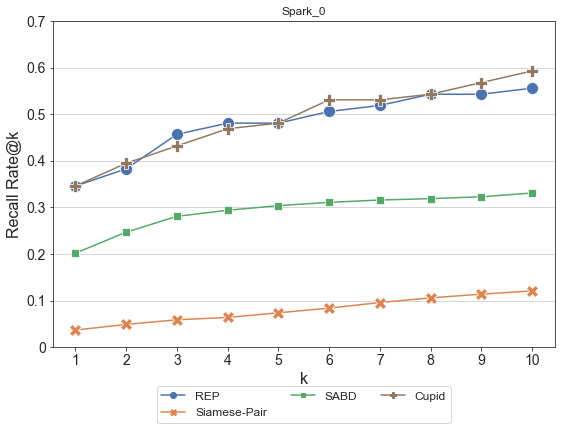

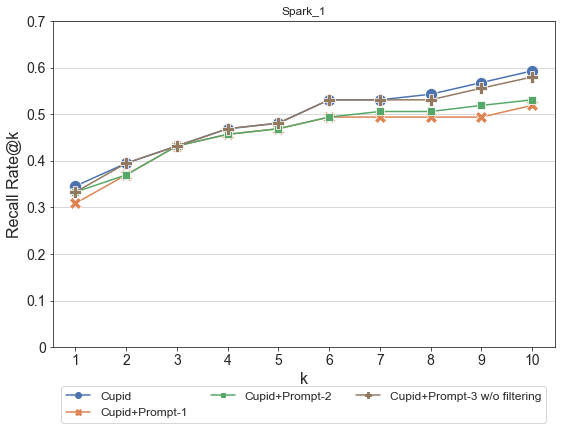

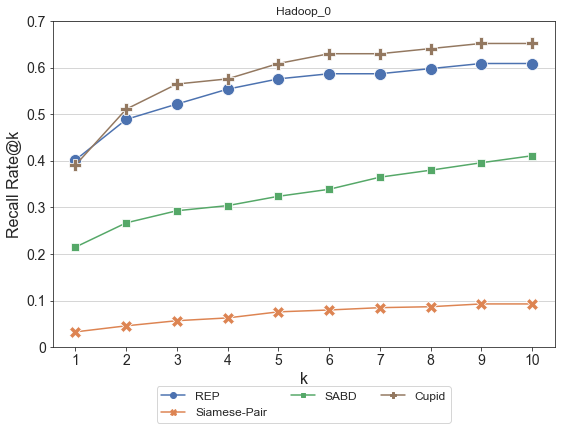

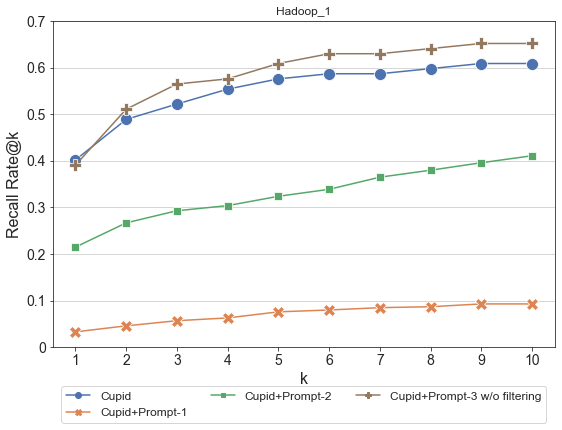

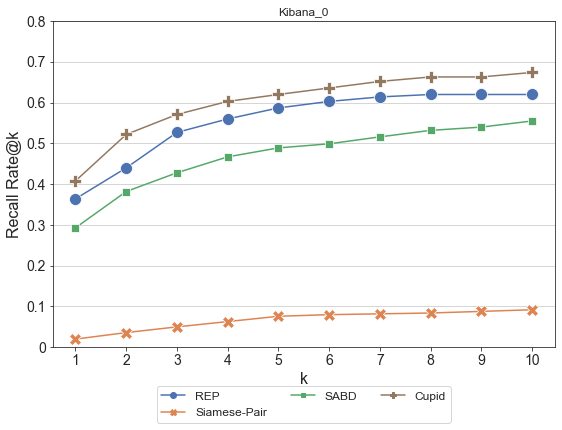

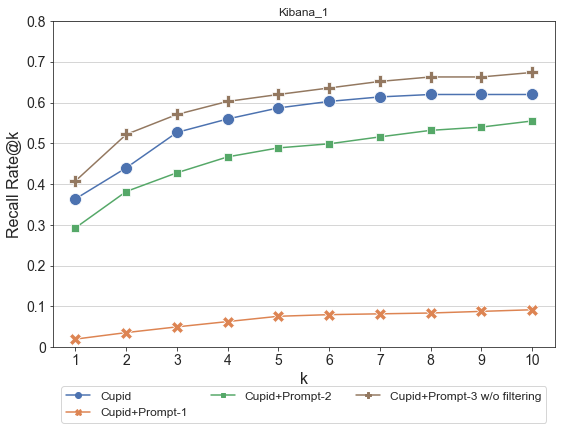

In [16]:
# Comparison (2 charts)

from tkinter import Y, font

# 0: Standard, 1: Ablation Study
raw_num = {
    "Spark": {0: """0.346	0.037	0.202	0.346
0.383	0.049	0.247	0.395
0.457	0.059	0.281	0.432
0.481	0.064	0.294	0.469
0.481	0.074	0.304	0.481
0.506	0.084	0.311	0.531
0.519	0.096	0.316	0.531
0.543	0.106	0.319	0.543
0.543	0.114	0.323	0.568
0.556	0.121	0.331	0.593""",
    1: """0.346	0.309	0.333	0.333
0.395	0.37	0.37	0.395
0.432	0.432	0.432	0.432
0.469	0.457	0.457	0.469
0.481	0.469	0.469	0.481
0.531	0.494	0.494	0.531
0.531	0.494	0.506	0.531
0.543	0.494	0.506	0.531
0.568	0.494	0.519	0.556
0.593	0.519	0.531	0.58""",},
    "Hadoop": {0: """0.402	0.033	0.215	0.391
0.489	0.046	0.267	0.511
0.522	0.057	0.293	0.565
0.554	0.063	0.304	0.576
0.576	0.076	0.324	0.609
0.587	0.08	0.339	0.63
0.587	0.085	0.365	0.63
0.598	0.087	0.38	0.641
0.609	0.093	0.396	0.652
0.609	0.093	0.411	0.652""",
    1: """0.402	0.033	0.215	0.391
0.489	0.046	0.267	0.511
0.522	0.057	0.293	0.565
0.554	0.063	0.304	0.576
0.576	0.076	0.324	0.609
0.587	0.08	0.339	0.63
0.587	0.085	0.365	0.63
0.598	0.087	0.38	0.641
0.609	0.093	0.396	0.652
0.609	0.093	0.411	0.652""",},
    "Kibana": {0: """00.364	0.02	0.293	0.408
0.44	0.036	0.382	0.522
0.527	0.05	0.428	0.571
0.56	0.063	0.467	0.603
0.587	0.076	0.489	0.62
0.603	0.08	0.499	0.636
0.614	0.082	0.516	0.652
0.62	0.084	0.532	0.663
0.62	0.088	0.54	0.663
0.62	0.092	0.555	0.674""",
    1: """0.364	0.02	0.293	0.408
0.44	0.036	0.382	0.522
0.527	0.05	0.428	0.571
0.56	0.063	0.467	0.603
0.587	0.076	0.489	0.62
0.603	0.08	0.499	0.636
0.614	0.082	0.516	0.652
0.62	0.084	0.532	0.663
0.62	0.088	0.54	0.663
0.62	0.092	0.555	0.674""",}
}


col = {0: {0: "REP", 1: "Siamese-Pair", 2: "SABD", 3: "Cupid"}, 
       1: {0: "Cupid", 1: "Cupid+Prompt-1", 2: "Cupid+Prompt-2", 3: "Cupid+Prompt-3 w/o filtering"}}

order_list =  {0: ["REP", "Siamese-Pair", "SABD", "Cupid"], 
       1: ["Cupid", "Cupid+Prompt-1", "Cupid+Prompt-2", "Cupid+Prompt-3 w/o filtering"]}

for project_name in raw_num:
    project_data = raw_num[project_name]
    
    for type_id in project_data:
        numbers = project_data[type_id].replace('\n', '\t').split('\t')
        numbers = [float(x) for x in numbers]

        y_min = max(0, min(numbers)-0.05*(min(numbers)))
        y_max = min(1, max(numbers)+0.05*(max(numbers)))
        data = {}
    #     tech_order = {0: "REP", 1: "Siamese-Pair", 2: "SABD", 3: "DC-CNN", 4: "HINDBR", 5: "FTS"}
        tech_order = col[type_id]

        for i in range(len(numbers)):
            tid = i%4
            data[tech_order[tid]] = data.get(tech_order[tid], [])
            data[tech_order[tid]].append(numbers[i])
        
        recall_rate_res = {}
        for column in data:
            recall_rate_res[column] = np.asarray([data[column]])

        sn.set_style("ticks")
        flatui = ["#4C72B0", "#DD8452", "#55A868", "#937860"]
        sn.set_palette(sn.color_palette(flatui))

        plt.figure(figsize=(9, 6))

#         order = ["REP", "Siamese-Pair", "SABD", "DC-CNN", "HINDBR", "FTS"]
        order = order_list[type_id]
        k = list(range(1,11))
        ax = sn.lineplot(x="k",y='Recall Rate@k',ci='sd', hue='method', style='method', markers=True, markersize=12, dashes=False, data=convert2dataframe(recall_rate_res,order))
        ax.set(title=f'{project_name}_{type_id}')
        # ax.title.set_fontsize(14)

        import matplotlib.ticker as ticker
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
        ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles[0:], labels=labels[0:], loc='lower center')
        ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=12)

        # leg = ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=12)
        leg_lines = ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=12).get_lines()

        y_min = 0
        ax.set(ylim=(y_min, y_max))
        #  set the ticks first

        ax.set_xlabel("k",fontsize=16)
        ax.set_ylabel("Recall Rate@k",fontsize=16)
        tick = y_min
        tick_label=[int(0)]
        while tick <= y_max:
            tick_label.append(tick + 0.1)
            tick += 0.1

        ax.tick_params(labelsize=14)
        ax.set_yticks(tick_label)

        tick_label = [str(round(x,1)) for x in tick_label]
        tick_label[0] = int(0)
        ax.set_yticklabels(tick_label)

        ax.grid()
        ax.grid(axis='x')

        fig = ax.get_figure()
        fig.savefig(f"Comparison-{project_name}-{type_id}.pdf", format='pdf', bbox_inches='tight', pad_inches=0)